# Part 1 Recurrent Neural Networks

## 1.1 Data Preprocessing

In [1]:
# Character-level language model with GRU
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models

# Set random seeds to make results reproducible
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)


In [2]:
# Load text data
filename = "Lewis-Carroll-book.txt"

def read_alice():
    """Load the Alice dataset as one text string."""
    with open(filename, "r", encoding="utf-8") as f:
        text = f.read()
    text = text.lstrip('\ufeff') # Delete BOM character
    return text

text = read_alice()

print(f"Number of text lines: {len(text.splitlines())}\n")
for line in text.splitlines()[:15]:
    print(line)

print(f"\nData size (number of characters): {len(text)}")


# Create vocabulary
vocab = sorted(set(text))
vocab_size = len(vocab)
print(f"Vocabulary size (number of distinct characters): {vocab_size}")

# Mappings
char_to_idx = {char: idx for idx, char in enumerate(vocab)}
idx_to_char = np.array(vocab)

# Encode the full text
corpus = np.array([char_to_idx[char] for char in text], dtype=np.int32)


Number of text lines: 3761

The Project Gutenberg eBook of Alice’s Adventures in Wonderland, by Lewis Carroll

This eBook is for the use of anyone anywhere in the United States and
most other parts of the world at no cost and with almost no restrictions
whatsoever. You may copy it, give it away or re-use it under the terms
of the Project Gutenberg License included with this eBook or online at
www.gutenberg.org. If you are not located in the United States, you
will have to check the laws of the country where you are located before
using this eBook.

Title: Alice’s Adventures in Wonderland

Author: Lewis Carroll

Release Date: January, 1991 [eBook #11]

Data size (number of characters): 164046
Vocabulary size (number of distinct characters): 89


In [3]:
# Create sequences of consecutive 50 tokens
seq_length = 50
examples_per_epoch = len(corpus) // (seq_length + 1)

char_dataset = tf.data.Dataset.from_tensor_slices(corpus)
sequences = char_dataset.batch(seq_length + 1, drop_remainder=True)

def split_input_target(chunk):
    input_text = chunk[:-1]
    target_text = chunk[1:]
    return input_text, target_text

dataset = sequences.map(split_input_target)

print(f"\nNumber of sequences: {examples_per_epoch}")

# Convert dataset into NumPy arrays X and Y for later training
X = []
Y = []
for inp, tar in dataset:
    X.append(inp.numpy())
    Y.append(tar.numpy())

X = np.array(X, dtype=np.int32)
Y = np.array(Y, dtype=np.int32)

print("\nInput array shape:", X.shape)
print("Target array shape:", Y.shape)


Number of sequences: 3216

Input array shape: (3216, 50)
Target array shape: (3216, 50)


## 1.2 Neural Network Implementation and Summary

In [4]:
# Define model hyperparameters
embedding_dim = 256
hidden_units = 1024
batch_size = 64
epochs = 50
learning_rate = 1e-2

gru_initializer = tf.keras.initializers.GlorotUniform()

# Build the character-level GRU model
baseline_model = models.Sequential([
    layers.Embedding(input_dim=vocab_size, output_dim=embedding_dim), # embedding layer
    layers.GRU(  # GRU layer
        units=hidden_units,
        return_sequences=True,
        kernel_initializer=gru_initializer,
        recurrent_initializer=gru_initializer
    ),
    layers.Dense(vocab_size) # dense layer
])

# Build the model by specifying the input sequence shape
baseline_model.build(input_shape=(None, seq_length))

# Show the model summary
print("\nP1.2 Model Summary:")
baseline_model.summary()


P1.2 Model Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 50, 256)        │        22,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 50, 1024)       │     3,938,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 50, 89)         │        91,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,052,313 (15.46 MB)

 Trainable params: 4,052,313 (15.46 MB)

 Non-trainable params: 0 (0.00 B)

## 1.3 Training and Evaluation


In [5]:
# Loss Function
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

# Optimizer
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

# Compile the model
baseline_model.compile(optimizer=optimizer, loss=loss_fn)

# Create training dataset
train_dataset = tf.data.Dataset.from_tensor_slices((X, Y))

train_dataset = train_dataset.shuffle(
    buffer_size=len(X),
    reshuffle_each_iteration=True
)
train_dataset = train_dataset.batch(batch_size, drop_remainder=False)
train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)

# Train model
history = baseline_model.fit(train_dataset, epochs=epochs, verbose=1)

# Record mean loss and perplexity
epoch_losses = history.history["loss"]
epoch_perplexities = [np.exp(loss) for loss in epoch_losses]

print("\nEpoch-wise training results:")
for epoch, (loss, ppl) in enumerate(zip(epoch_losses, epoch_perplexities), start=1):
    print(f"Epoch {epoch:02d}: Mean Loss = {loss:.4f}, Perplexity = {ppl:.4f}")


Epoch 1/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - loss: 4.1881
Epoch 2/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 2.4012
Epoch 3/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 2.2375
Epoch 4/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 2.1298
Epoch 5/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 2.0534
Epoch 6/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 2.0021
Epoch 7/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 1.9474
Epoch 8/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 1.9103
Epoch 9/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 1.8831
Epoch 10/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 1.8503
Epoch 11/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 1.8256
Epoch 12/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 1.8154
Epoch 13/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 1.7958
Epoch 14/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 1.7803
Epoch 15/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 1.7686
Epoc

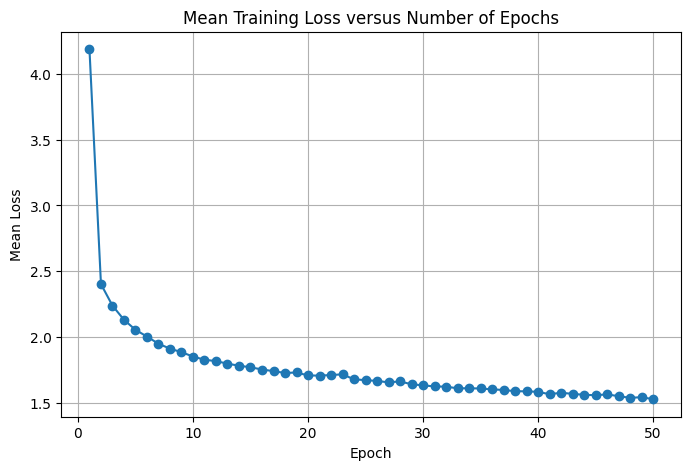

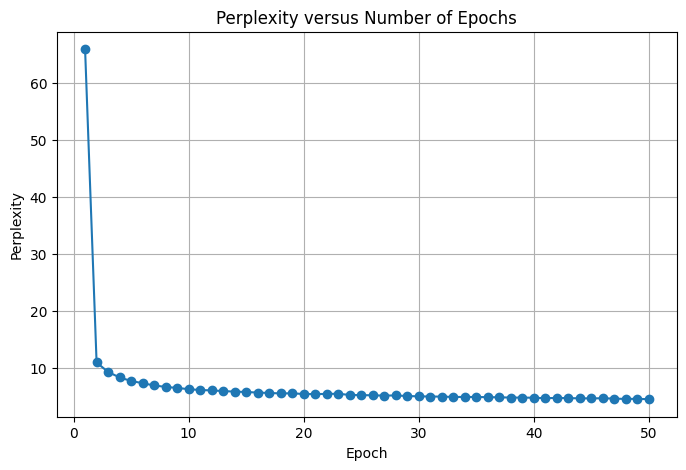

In [6]:
# Plot mean loss vs epoch
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), epoch_losses, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Mean Loss")
plt.title("Mean Training Loss versus Number of Epochs")
plt.grid(True)
plt.show()

# Plot perplexity vs epoch
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), epoch_perplexities, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Perplexity")
plt.title("Perplexity versus Number of Epochs")
plt.grid(True)
plt.show()


The training loss decreases rapidly in the first few epochs and then gradually stabilises. It drops from approximately 4.2 to around 1.5 by epoch 50, showing that the model is learning effectively. The sharp decrease at the beginning suggests that the model quickly captures basic character patterns, while later epochs provide smaller improvements.

The perplexity follows a similar trend, decreasing significantly at the start and reaching around 4.6 at the end. Given a vocabulary of 89 characters, this means the model has effectively narrowed its predictions down to fewer than 5 candidates at each step, which indicates a strong improvement in predictive confidence over training.

Overall, the training process is stable, with no major fluctuations in loss or perplexity. The learning rate of 1e-2 works well, although most of the improvement happens in the early epochs. Since only training metrics are shown, overfitting cannot be evaluated.

## 1.4 Hyper-parameter Tuning and Language Generatio

In [11]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Character-level vocabulary size
char_vocab_size = len(idx_to_char)

# Build training dataset
char_train_dataset = tf.data.Dataset.from_tensor_slices((X, Y))
char_train_dataset = char_train_dataset.shuffle(
    buffer_size=len(X), reshuffle_each_iteration=True
)
char_train_dataset = char_train_dataset.batch(batch_size, drop_remainder=False)
char_train_dataset = char_train_dataset.prefetch(tf.data.AUTOTUNE)

# Generate text from the trained model
def generate_text(model, start_char="I", num_chars=100):
    outputs = [start_char]

    for _ in range(num_chars - 1):
        input_ids = [char_to_idx[ch] for ch in outputs]
        input_padded = pad_sequences([input_ids], maxlen=seq_length, padding='pre')

        y_hat = model.predict(input_padded, verbose=0)
        y = y_hat[0, -1]

        probs = tf.nn.softmax(y).numpy()
        next_idx = int(np.argmax(probs))
        next_char = idx_to_char[next_idx]

        outputs.append(next_char)

    return "".join(outputs)

# Callback for text generation and checkpoint saving
class GenerateTextCallback(tf.keras.callbacks.Callback):
    def __init__(self, checkpoint_manager, start_char="I", num_chars=100):
        super().__init__()
        self.checkpoint_manager = checkpoint_manager
        self.start_char = start_char
        self.num_chars = num_chars
        self.generated_texts = {}

    def on_epoch_end(self, epoch, logs=None):
        epoch_num = epoch + 1
        if epoch_num % 5 == 0:
            text = generate_text(self.model, self.start_char, self.num_chars)
            self.generated_texts[epoch_num] = text
            print(f"\nGenerated text after epoch {epoch_num}:")
            print(text)
            self.checkpoint_manager.save()

# Rebuild baseline model
baseline_model_p14 = models.Sequential([
    layers.Embedding(input_dim=char_vocab_size, output_dim=embedding_dim),
    layers.GRU(
        units=hidden_units,
        return_sequences=True,
        kernel_initializer=gru_initializer,
        recurrent_initializer=gru_initializer
    ),
    layers.Dense(char_vocab_size)
])

baseline_model_p14.build(input_shape=(None, seq_length))
print("\nP1.4 Baseline Model Summary:")
baseline_model_p14.summary()

# Compile and train model
baseline_optimizer_p14 = tf.keras.optimizers.Adam(learning_rate=learning_rate)
baseline_loss_p14 = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

baseline_model_p14.compile(
    optimizer=baseline_optimizer_p14,
    loss=baseline_loss_p14
)

baseline_ckpt = tf.train.Checkpoint(
    optimizer=baseline_optimizer_p14,
    model=baseline_model_p14
)

baseline_ckpt_manager = tf.train.CheckpointManager(
    baseline_ckpt,
    directory="./baseline_checkpoints",
    max_to_keep=10
)

baseline_callback = GenerateTextCallback(
    baseline_ckpt_manager,
    start_char="I",
    num_chars=100
)


baseline_history_p14 = baseline_model_p14.fit(
    char_train_dataset,
    epochs=epochs,
    callbacks=[baseline_callback],
    verbose=1
)

# Show generated text samples
print("\nGenerated text samples every 5 epochs (baseline model):\n")
for epoch_num in sorted(baseline_callback.generated_texts.keys()):
    print(f"Epoch {epoch_num}:")
    print(baseline_callback.generated_texts[epoch_num])
    print()


P1.4 Baseline Model Summary:


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 50, 256)        │        22,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_5 (GRU)                     │ (None, 50, 1024)       │     3,938,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 50, 89)         │        91,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,052,313 (15.46 MB)

 Trainable params: 4,052,313 (15.46 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 4.7653
Epoch 2/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 2.4639
Epoch 3/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 2.2950
Epoch 4/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 2.1791
Epoch 5/50
49/51 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 2.1170
Generated text after epoch 5:
I with the Caten the Mout of the Caten the Mout of the Mout the Mout the Mouth the Cater the Caten t
51/51 ━━━━━━━━━━━━━━━━━━━━ 11s 218ms/step - loss: 2.0934
Epoch 6/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - loss: 2.0214
Epoch 7/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 1.9714
Epoch 8/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 1.9351
Epoch 9/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 1.9111
Epoch 10/50
49/51 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 1.8918
Generated text after epoch 10:
I caut she was and the Dore with and the Dore and the Dore and the Dore and the the the Dore and the
51/51 ━━━━━━━━━━━━

In [12]:
# Improved model: larger hidden size
improved_hidden_units = 1536

improved_model = models.Sequential([
    layers.Embedding(input_dim=char_vocab_size, output_dim=embedding_dim),
    layers.GRU(
        units=improved_hidden_units,
        return_sequences=True,
        kernel_initializer=gru_initializer,
        recurrent_initializer=gru_initializer
    ),
    layers.Dense(char_vocab_size)
])

improved_model.build(input_shape=(None, seq_length))
print("\nImproved Model Summary:")
improved_model.summary()

# Compile model
improved_optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
improved_loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

improved_model.compile(
    optimizer=improved_optimizer,
    loss=improved_loss
)

# Create checkpoint manager
improved_ckpt = tf.train.Checkpoint(
    optimizer=improved_optimizer,
    model=improved_model
)

improved_ckpt_manager = tf.train.CheckpointManager(
    improved_ckpt,
    directory="./improved_checkpoints",
    max_to_keep=10
)

improved_callback = GenerateTextCallback(
    improved_ckpt_manager,
    start_char="I",
    num_chars=100
)

# Train model
improved_history = improved_model.fit(
    char_train_dataset,
    epochs=epochs,
    callbacks=[improved_callback],
    verbose=1
)

# Generated text samples
print("\nGenerated text samples every 5 epochs (improved model):\n")
for epoch_num in sorted(improved_callback.generated_texts.keys()):
    print(f"Epoch {epoch_num}:")
    print(improved_callback.generated_texts[epoch_num])
    print()


Improved Model Summary:


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ (None, 50, 256)        │        22,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_6 (GRU)                     │ (None, 50, 1536)       │     8,266,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 50, 89)         │       136,793 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,426,329 (32.14 MB)

 Trainable params: 8,426,329 (32.14 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - loss: 5.6552
Epoch 2/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - loss: 2.5109
Epoch 3/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - loss: 2.3703
Epoch 4/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - loss: 2.2600
Epoch 5/50
50/51 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 2.1976
Generated text after epoch 5:
I mare the Hare the Hare the Hare the Hare the Hary the Hare the Hare the Hare the Hare the Hare the
51/51 ━━━━━━━━━━━━━━━━━━━━ 11s 219ms/step - loss: 2.1858
Epoch 6/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - loss: 2.1535
Epoch 7/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - loss: 2.1189
Epoch 8/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - loss: 2.0965
Epoch 9/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - loss: 2.0710
Epoch 10/50
50/51 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 2.0721
Generated text after epoch 10:
I’d the Raris Guter she said the Grarting the Rarith as a she the Quee as as a she said the Quee as 
51/51 ━━━━━━━━━━━━━

The generated text improves over time for both models. In the first few epochs, the output is mostly repeated words and incomplete text, showing that the model has only learned simple character patterns. As training continues, the model starts to generate words and names from the original text, although repetition is still common.

For the improved model, I increased the hidden size from 1024 to 1536, which leads to slightly better outputs with more plausible word fragments. However, the improvement is limited and the text is still not fully coherent.

A deep RNN with two GRU layers was also tested, but the results were worse. The generated text became more repetitive and less stable, likely because the added complexity makes the model harder to optimise under the same hyperparameter settings. This configuration was therefore not used in the final model.

Overall, increasing the hidden size provides some improvement, while simply adding more layers does not necessarily help in this case. The key limitation of both models is the greedy decoding strategy, which would be a natural direction for further improvement.

# Part 2 Word-level Language Model

## 2.1 Word-level Language Model

In [43]:
from tensorflow.keras.preprocessing.text import Tokenizer

# Load text
text = read_alice()

# Build word-level vocabulary
word_tokenizer = Tokenizer()
word_tokenizer.fit_on_texts([text])

word_index = word_tokenizer.word_index
index_word = {i: w for w, i in word_index.items()}
vocab_size = len(word_index) + 1

print("Word-level vocabulary size:", vocab_size)

# Encode text into word indices
encoded = word_tokenizer.texts_to_sequences([text])[0]

print("Number of word tokens:", len(encoded))
print("First 20 tokens:", encoded[:20])

# Create input-target sequences
seq_length = 50
X = []
Y = []

for i in range(0, len(encoded) - seq_length):
    chunk = encoded[i:i + seq_length + 1]
    input_seq = chunk[:-1]
    target_seq = chunk[1:]
    X.append(input_seq)
    Y.append(target_seq)

X = np.array(X, dtype=np.int32)
Y = np.array(Y, dtype=np.int32)

print("X shape:", X.shape)
print("Y shape:", Y.shape)


Word-level vocabulary size: 3533
Number of word tokens: 30987
First 20 tokens: [1, 46, 41, 314, 6, 249, 406, 10, 556, 48, 992, 993, 22, 314, 34, 24, 1, 144, 6, 699]
X shape: (30937, 50)
Y shape: (30937, 50)


In [44]:
# Build training dataset
batch_size = 64
train_dataset = tf.data.Dataset.from_tensor_slices((X, Y))
train_dataset = train_dataset.shuffle(buffer_size=len(X), reshuffle_each_iteration=True)
train_dataset = train_dataset.batch(batch_size)
train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)

# Build GRU model
embedding_dim = 256
hidden_units = 1024
epochs = 30
learning_rate = 1e-2

# Reset random seeds before building word-level model
np.random.seed(42)
tf.random.set_seed(42)

word_model = models.Sequential([
    layers.Embedding(input_dim=vocab_size, output_dim=embedding_dim),
    layers.GRU(
        units=hidden_units,
        return_sequences=True,
        kernel_initializer=tf.keras.initializers.GlorotUniform(),
        recurrent_initializer=tf.keras.initializers.GlorotUniform()
    ),
    layers.Dense(vocab_size)
])

word_model.build(input_shape=(None, seq_length))
word_model.summary()



Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_14 (Embedding)        │ (None, 50, 256)        │       904,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_14 (GRU)                    │ (None, 50, 1024)       │     3,938,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 50, 3533)       │     3,621,325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,464,077 (32.29 MB)

 Trainable params: 8,464,077 (32.29 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
484/484 ━━━━━━━━━━━━━━━━━━━━ 34s 67ms/step - loss: 6.1621
Epoch 2/30
484/484 ━━━━━━━━━━━━━━━━━━━━ 31s 65ms/step - loss: 5.1183
Epoch 3/30
484/484 ━━━━━━━━━━━━━━━━━━━━ 31s 65ms/step - loss: 4.8085
Epoch 4/30
484/484 ━━━━━━━━━━━━━━━━━━━━ 32s 65ms/step - loss: 5.8984
Epoch 5/30
484/484 ━━━━━━━━━━━━━━━━━━━━ 31s 65ms/step - loss: 4.6143
Epoch 6/30
484/484 ━━━━━━━━━━━━━━━━━━━━ 31s 65ms/step - loss: 4.1252
Epoch 7/30
484/484 ━━━━━━━━━━━━━━━━━━━━ 31s 64ms/step - loss: 3.8449
Epoch 8/30
484/484 ━━━━━━━━━━━━━━━━━━━━ 31s 65ms/step - loss: 3.6601
Epoch 9/30
484/484 ━━━━━━━━━━━━━━━━━━━━ 31s 64ms/step - loss: 3.4935
Epoch 10/30
484/484 ━━━━━━━━━━━━━━━━━━━━ 31s 65ms/step - loss: 3.2463
Epoch 11/30
484/484 ━━━━━━━━━━━━━━━━━━━━ 31s 65ms/step - loss: 3.0352
Epoch 12/30
484/484 ━━━━━━━━━━━━━━━━━━━━ 31s 65ms/step - loss: 2.8453
Epoch 13/30
484/484 ━━━━━━━━━━━━━━━━━━━━ 31s 65ms/step - loss: 2.6813
Epoch 14/30
484/484 ━━━━━━━━━━━━━━━━━━━━ 31s 65ms/step - loss: 2.5109
Epoch 15/30
484/484 ━━━━━━━━━

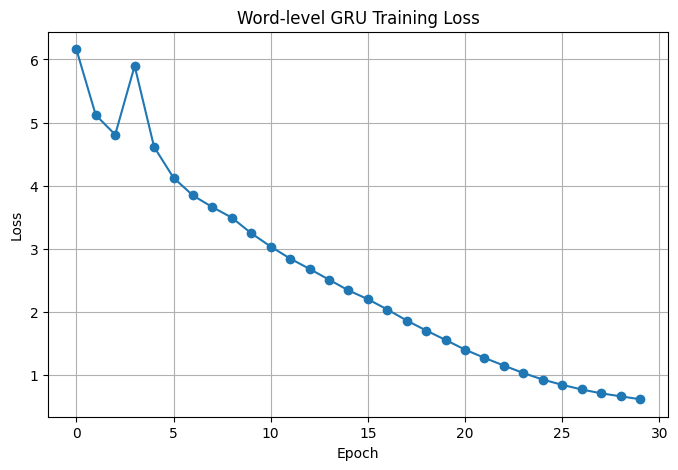

In [45]:
# Compile and train model
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

word_model.compile(optimizer=optimizer, loss=loss_fn)
history = word_model.fit(train_dataset, epochs=epochs, verbose=1)

# Plot training loss
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], marker="o")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Word-level GRU Training Loss")
plt.grid(True)
plt.show()

In [46]:
# Generate text from word-level model
def generate_word_text(model, start_word="alice", num_tokens=50):
    generated = [start_word]

    for _ in range(num_tokens - 1):
        input_ids = [word_index[w] for w in generated if w in word_index]
        # pad to fixed seq_length with pre-padding, consistent with training input size
        input_padded = pad_sequences([input_ids], maxlen=seq_length, padding='pre')

        y_hat = model.predict(input_padded, verbose=0)
        logits = y_hat[0, -1]
        probs = tf.nn.softmax(logits).numpy()

        next_idx = int(np.argmax(probs))
        next_word = index_word.get(next_idx, "")

        if next_word == "":
            break

        generated.append(next_word)

    text_out = " ".join(generated)

    if text_out.startswith("alice"):
        text_out = "Alice" + text_out[len("alice"):]

    return text_out

generated = generate_word_text(word_model, start_word="alice", num_tokens=50)

print("\nGenerated text:")
print(generated)


Generated text:
Alice got in the schoolroom and though this was by it and found a little hand in a very difficult question however she stretched her arms and the gryphon and the gryphon answered in the house if he in a tone of great other intellectual property infringement a defective or


The training loss generally decreases throughout the 30 epochs, which shows that the model is learning from the data. There is a small increase in the early stage, but after that the loss keeps falling and reaches around 0.62 at the end. It reaches around 0.62 by the end, which is noticeably lower than the character-level model. A loss this low on a small corpus suggests the model may be overfitting, essentially memorising word sequences rather than generalising.

The generated text is more readable than the character-level output because the model works directly with words instead of individual characters. It can generate some reasonable phrases and short parts that look similar to normal English. However, the whole sentence is still not fully meaningful, and the ending becomes strange and out of context. This means the model learns local word patterns quite well, but it still has difficulty keeping the whole sentence coherent.

Overall, the word-level model gives better readability, but the generated text is still imperfect.

## 2.2 Pre-trained Embeddings

In [17]:
import urllib.request
import zipfile

url = "https://nlp.stanford.edu/data/glove.6B.zip"
urllib.request.urlretrieve(url, "glove.6B.zip")

with zipfile.ZipFile("glove.6B.zip", "r") as zip_ref:
    zip_ref.extract("glove.6B.50d.txt", ".")

In [47]:
# Reuse dataset from P2.1
vocab_size = len(word_index) + 1
batch_size = 64

train_dataset = tf.data.Dataset.from_tensor_slices((X, Y))
train_dataset = train_dataset.shuffle(buffer_size=len(X), reshuffle_each_iteration=True)
train_dataset = train_dataset.batch(batch_size, drop_remainder=False)
train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)

# Load pre-trained GloVe embeddings
embedding_dim = 50
glove_path = "glove.6B.50d.txt"

embeddings_index = {}
with open(glove_path, "r", encoding="utf-8") as f:
    for line in f:
        values = line.strip().split()
        word = values[0]
        vector = np.asarray(values[1:], dtype="float32")
        embeddings_index[word] = vector

print("Loaded GloVe vectors:", len(embeddings_index))

# Build embedding matrix
embedding_matrix = np.zeros((vocab_size, embedding_dim), dtype=np.float32)
matched = 0

for word, i in word_index.items():
    vector = embeddings_index.get(word)
    if vector is None:
        vector = embeddings_index.get(word.lower())
    if vector is not None:
        embedding_matrix[i] = vector
        matched += 1

print("Matched words:", matched)
print("Coverage:", matched / len(word_index))



Loaded GloVe vectors: 400000
Matched words: 2939
Coverage: 0.8321064552661381


In [48]:
# Build GRU model with fixed pre-trained embeddings
hidden_units = 1024
epochs = 30
learning_rate = 1e-2

pretrained_model = models.Sequential([
    layers.Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        embeddings_initializer=tf.keras.initializers.Constant(embedding_matrix),
        trainable=False
    ),
    layers.GRU(
        units=hidden_units,
        return_sequences=True,
        kernel_initializer=tf.keras.initializers.GlorotUniform(),
        recurrent_initializer=tf.keras.initializers.GlorotUniform()
    ),
    layers.Dense(vocab_size)
])

pretrained_model.build(input_shape=(None, X.shape[1]))
pretrained_model.summary()


Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_15 (Embedding)        │ (None, 50, 50)         │       176,650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_15 (GRU)                    │ (None, 50, 1024)       │     3,305,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 50, 3533)       │     3,621,325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,103,447 (27.10 MB)

 Trainable params: 6,926,797 (26.42 MB)

 Non-trainable params: 176,650 (690.04 KB)

Epoch 1/30
484/484 ━━━━━━━━━━━━━━━━━━━━ 31s 61ms/step - loss: 3.6794
Epoch 2/30
484/484 ━━━━━━━━━━━━━━━━━━━━ 29s 61ms/step - loss: 3.2673
Epoch 3/30
484/484 ━━━━━━━━━━━━━━━━━━━━ 30s 61ms/step - loss: 2.8585
Epoch 4/30
484/484 ━━━━━━━━━━━━━━━━━━━━ 29s 61ms/step - loss: 2.6434
Epoch 5/30
484/484 ━━━━━━━━━━━━━━━━━━━━ 29s 61ms/step - loss: 3.0119
Epoch 6/30
484/484 ━━━━━━━━━━━━━━━━━━━━ 30s 61ms/step - loss: 2.7560
Epoch 7/30
484/484 ━━━━━━━━━━━━━━━━━━━━ 29s 61ms/step - loss: 2.4274
Epoch 8/30
484/484 ━━━━━━━━━━━━━━━━━━━━ 29s 61ms/step - loss: 2.3917
Epoch 9/30
484/484 ━━━━━━━━━━━━━━━━━━━━ 29s 61ms/step - loss: 2.2648
Epoch 10/30
484/484 ━━━━━━━━━━━━━━━━━━━━ 30s 63ms/step - loss: 1.9483
Epoch 11/30
484/484 ━━━━━━━━━━━━━━━━━━━━ 30s 61ms/step - loss: 1.7318
Epoch 12/30
484/484 ━━━━━━━━━━━━━━━━━━━━ 29s 61ms/step - loss: 1.6264
Epoch 13/30
484/484 ━━━━━━━━━━━━━━━━━━━━ 30s 61ms/step - loss: 1.7341
Epoch 14/30
484/484 ━━━━━━━━━━━━━━━━━━━━ 30s 62ms/step - loss: 1.7928
Epoch 15/30
484/484 ━━━━━━━━━

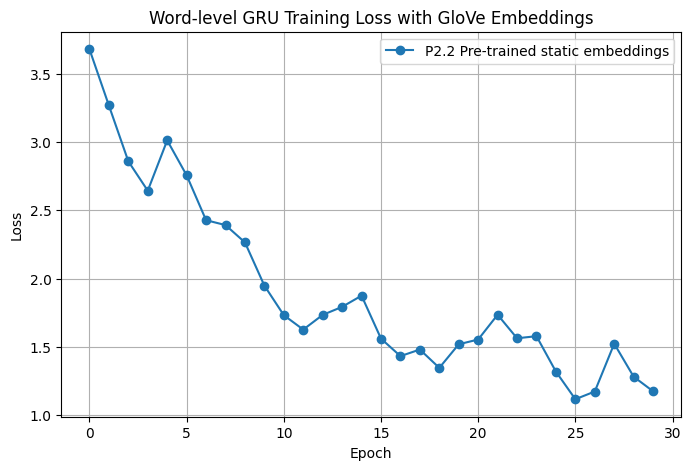

In [50]:
# Compile and train model
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

pretrained_model.compile(optimizer=optimizer, loss=loss_fn)
history_pretrained = pretrained_model.fit(train_dataset, epochs=epochs, verbose=1)

# Plot training loss
plt.figure(figsize=(8, 5))
plt.plot(history_pretrained.history["loss"], marker="o", label="P2.2 Pre-trained static embeddings")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Word-level GRU Training Loss with GloVe Embeddings")
plt.grid(True)
plt.legend()
plt.show()

In [51]:
def generate_word_text(model, start_word="alice", num_tokens=50):
    generated = [start_word]

    for _ in range(num_tokens - 1):
        input_ids = [word_index[w] for w in generated if w in word_index]
        input_padded = pad_sequences([input_ids], maxlen=seq_length, padding='pre')

        y_hat = model.predict(input_padded, verbose=0)
        logits = y_hat[0, -1]
        probs = tf.nn.softmax(logits).numpy()

        next_idx = int(np.argmax(probs))
        next_word = index_word.get(next_idx, "")

        if next_word == "":
            break

        generated.append(next_word)

    text_out = " ".join(generated)

    if text_out.startswith("alice"):
        text_out = "Alice" + text_out[len("alice"):]

    return text_out

print("\nGenerated text with pre-trained static embeddings:")
print(generate_word_text(pretrained_model, start_word="alice", num_tokens=50))


Generated text with pre-trained static embeddings:
Alice come here directly all the dormouse say and some of this they all not remember ever was not going out one of course house and after a doze but they very anxiously into its face was not a very small one of the next thing it was not be


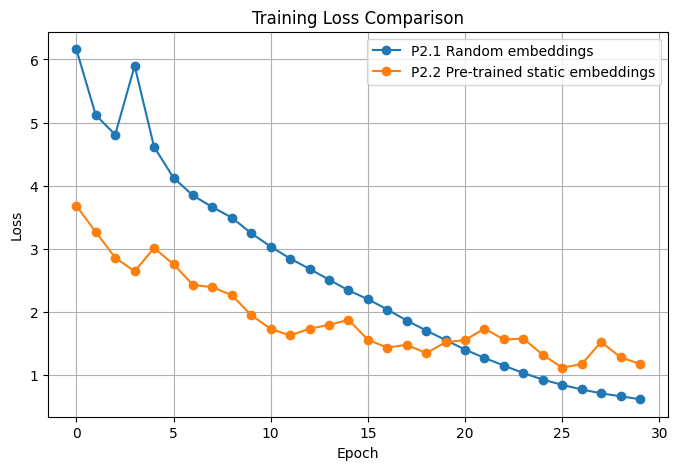

In [52]:
# Compare training loss with P2.1
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], marker="o", label="P2.1 Random embeddings")
plt.plot(history_pretrained.history["loss"], marker="o", label="P2.2 Pre-trained static embeddings")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.grid(True)
plt.legend()
plt.show()

The model with pre-trained static embeddings also learns during training, since the loss generally goes down over the 30 epochs. However, compared with the previous word-level GRU with random embeddings, the final loss is higher and the curve is a bit less stable.

The generated text is still more readable than character-level output, and it contains some reasonable word combinations. This means the pre-trained embeddings do provide useful information about words. However, the whole sequence is still not very coherent, and the result is not clearly better than the previous model.

From the loss comparison, the random-embedding model actually performs better in this task. One possible reason is that the pre-trained embeddings were kept static, so they could not adapt to the specific language style of the corpus. In contrast, randomly initialised embeddings can be learned directly from the book and may fit the task better.

Overall, using pre-trained static embeddings did not improve the model here, and the previous word-level GRU performed better.

# Part3 Transformers

## 3.1 Transformer Implementation

In [56]:
# Transformer hyperparameters
embedding_dim = 256
num_heads = 4
ff_dim = 512
dropout_rate = 0.1
epochs = 50
learning_rate = 1e-2

# Positional embedding layer
class PositionalEmbedding(layers.Layer):
    def __init__(self, seq_length, vocab_size, embedding_dim):
        super().__init__()
        self.token_embedding = layers.Embedding(input_dim=vocab_size, output_dim=embedding_dim)
        self.position_embedding = layers.Embedding(input_dim=seq_length, output_dim=embedding_dim)

    def call(self, x):
        length = tf.shape(x)[-1]
        positions = tf.range(start=0, limit=length, delta=1)
        positions = self.position_embedding(positions)
        x = self.token_embedding(x)
        return x + positions

# One decoder block
def decoder_block(x, embedding_dim, num_heads, ff_dim, dropout_rate):
    attn_output = layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=embedding_dim // num_heads
    )(x, x, use_causal_mask=True)

    attn_output = layers.Dropout(dropout_rate)(attn_output)
    x = layers.LayerNormalization(epsilon=1e-6)(x + attn_output)

    ffn_output = layers.Dense(ff_dim, activation="relu")(x)
    ffn_output = layers.Dense(embedding_dim)(ffn_output)
    ffn_output = layers.Dropout(dropout_rate)(ffn_output)
    x = layers.LayerNormalization(epsilon=1e-6)(x + ffn_output)

    return x



In [57]:
# Build decoder-only Transformer
inputs = layers.Input(shape=(seq_length,), dtype=tf.int32)

x = PositionalEmbedding(seq_length, vocab_size, embedding_dim)(inputs)
x = decoder_block(x, embedding_dim, num_heads, ff_dim, dropout_rate)

outputs = layers.Dense(vocab_size)(x)

transformer_model = models.Model(inputs=inputs, outputs=outputs)

print("Transformer model summary:")
transformer_model.summary()

# Compile and train model
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

transformer_model.compile(optimizer=optimizer, loss=loss_fn)

transformer_history = transformer_model.fit(
    train_dataset,
    epochs=epochs,
    verbose=1
)

# Record loss and perplexity
transformer_losses = transformer_history.history["loss"]
transformer_perplexities = [np.exp(loss) for loss in transformer_losses]

print("\nEpoch-wise training results (Transformer):")
for epoch, (loss, ppl) in enumerate(zip(transformer_losses, transformer_perplexities), start=1):
    print(f"Epoch {epoch:02d}: Mean Loss = {loss:.4f}, Perplexity = {ppl:.4f}")



Transformer model summary:


Model: "functional_18"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_18      │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_embeddi… │ (None, 50, 256)   │    917,248 │ input_layer_18[0… │
│ (PositionalEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 50, 256)   │    263,168 │ positional_embed… │
│ (MultiHeadAttentio… │                   │            │ positional_embed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 50, 256)   │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 50, 256)   │          0 │ positional_embed… │
│                     │                   │            │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 50, 256)   │        512 │ add_4[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_22 (Dense)    │ (None, 50, 512)   │    131,584 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_23 (Dense)    │ (None, 50, 256)   │    131,328 │ dense_22[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 50, 256)   │          0 │ dense_23[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, 50, 256)   │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 50, 256)   │        512 │ add_5[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_24 (Dense)    │ (None, 50, 3533)  │    907,981 │ layer_normalizat… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,352,333 (8.97 MB)

 Trainable params: 2,352,333 (8.97 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 20s 23ms/step - loss: 1.9067
Epoch 2/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - loss: 0.3501
Epoch 3/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.3070
Epoch 4/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - loss: 0.2764
Epoch 5/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - loss: 0.2657
Epoch 6/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - loss: 0.2546
Epoch 7/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - loss: 0.2589
Epoch 8/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.2779
Epoch 9/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.2986
Epoch 10/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - loss: 0.3356
Epoch 11/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - loss: 0.3508
Epoch 12/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - loss: 0.3513
Epoch 13/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.3692
Epoch 14/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.3668
Epoch 15/50
484/484 ━━━━━━━━━━━━━━━━━━━━ 7

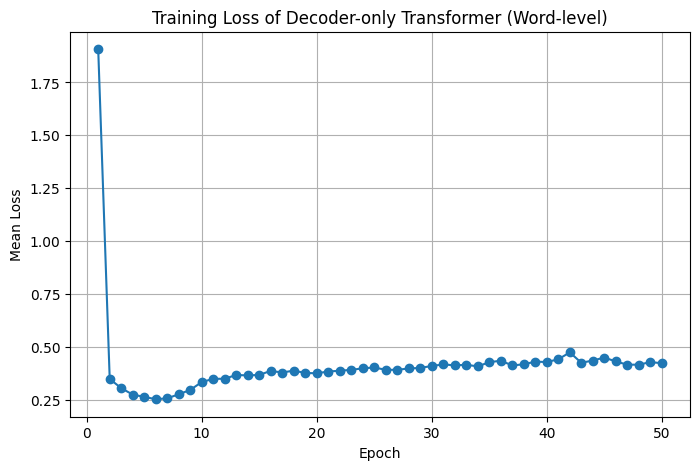

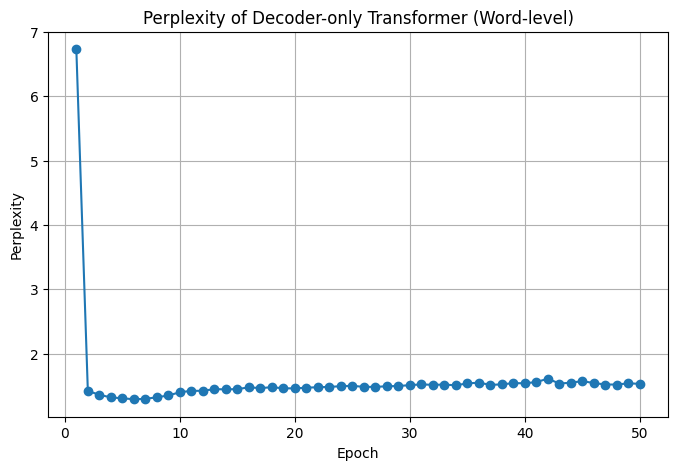

In [58]:
# Plot training loss
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(transformer_losses) + 1), transformer_losses, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Mean Loss")
plt.title("Training Loss of Decoder-only Transformer (Word-level)")
plt.grid(True)
plt.show()

# Plot perplexity
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(transformer_perplexities) + 1), transformer_perplexities, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Perplexity")
plt.title("Perplexity of Decoder-only Transformer (Word-level)")
plt.grid(True)
plt.show()


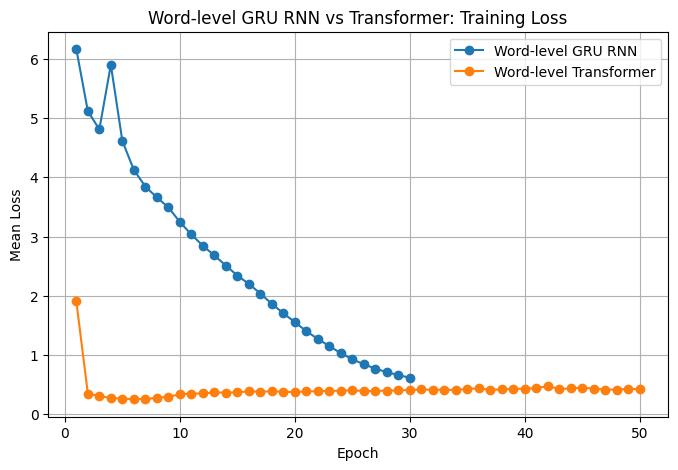

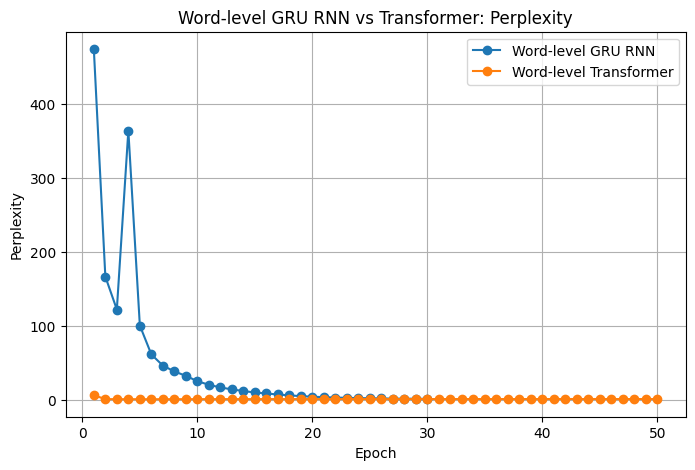

In [59]:
# Compare with the word-level GRU model from P2.1
p2_losses = history.history["loss"]
p2_perplexities = [np.exp(loss) for loss in p2_losses]

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(p2_losses) + 1), p2_losses, marker='o', label='Word-level GRU RNN')
plt.plot(range(1, len(transformer_losses) + 1), transformer_losses, marker='o', label='Word-level Transformer')
plt.xlabel("Epoch")
plt.ylabel("Mean Loss")
plt.title("Word-level GRU RNN vs Transformer: Training Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(p2_perplexities) + 1), p2_perplexities, marker='o', label='Word-level GRU RNN')
plt.plot(range(1, len(transformer_perplexities) + 1), transformer_perplexities, marker='o', label='Word-level Transformer')
plt.xlabel("Epoch")
plt.ylabel("Perplexity")
plt.title("Word-level GRU RNN vs Transformer: Perplexity")
plt.legend()
plt.grid(True)
plt.show()


In [69]:
# Generate text with greedy decoding
def generate_text_transformer(model, start_word="alice", num_tokens=50):
    generated = [start_word]

    for _ in range(num_tokens - 1):
        input_ids = [word_index[w] for w in generated if w in word_index]
        current_input = input_ids[-seq_length:]

        if len(current_input) < seq_length:
            pad_len = seq_length - len(current_input)
            current_input = [0] * pad_len + current_input

        input_eval = tf.expand_dims(current_input, 0)

        y = model(input_eval, training=False)
        probs = tf.nn.softmax(y[0, -1]).numpy()

        next_idx = int(np.argmax(probs))
        next_word = index_word.get(next_idx, "")

        if next_word == "":
            break

        generated.append(next_word)

    text_out = " ".join(generated)

    if text_out.startswith("alice"):
        text_out = "Alice" + text_out[len("alice"):]

    return text_out

print("Generated text from Transformer:")
print(generate_text_transformer(transformer_model, start_word="alice", num_tokens=50))

Generated text from Transformer:
Alice could not gone far down to be true if she said the fall never come down the rabbit’s little white kid gloves while she was talking “how can i have done that ” thought “i must be growing small again ” she got up and went in a last


The decoder-only transformer performs better than the word-level GRU overall. Its training loss and perplexity drop much faster in the beginning, which shows that it learns the text patterns more efficiently. Although the transformer loss goes up slightly after the early epochs, it still stays lower than the GRU.

The generated text from the transformer is also better. It is more fluent, less repetitive, and more similar to the style of the original book. Compared with the GRU, it produces more meaningful phrases and has better sentence-level consistency.

This is probably because the transformer uses self-attention, so it can model relationships between words more effectively than the GRU. Overall, the transformer gives better results than the RNN in this task, although the training curves suggest that it may start to overfit or become less stable after enough epochs.

## 3.2 Pre-trained Transformer

In [83]:
# P3.2 Pre-trained Transformer (distilgpt2)

!pip install -q transformers torch

import torch
from torch.utils.data import TensorDataset, DataLoader
from torch.optim import AdamW
from transformers import GPT2Tokenizer, GPT2LMHeadModel

# Load distilgpt2
np.random.seed(42)

model_name = "distilgpt2"

gpt2_tokenizer = GPT2Tokenizer.from_pretrained(model_name)
gpt2_tokenizer.pad_token = gpt2_tokenizer.eos_token

gpt2_model = GPT2LMHeadModel.from_pretrained(model_name)
gpt2_model.config.pad_token_id = gpt2_tokenizer.eos_token_id

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
gpt2_model = gpt2_model.to(device)

print(f"Loaded model: {model_name}")
print(f"Device: {device}")
print(f"Vocabulary size: {gpt2_tokenizer.vocab_size}")


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded model: distilgpt2
Device: cuda
Vocabulary size: 50257


In [87]:
# Tokenise Alice corpus
text = read_alice()
token_ids = gpt2_tokenizer.encode(text)
print(f"Number of GPT-2 tokens in corpus: {len(token_ids)}")

# Create dataset
block_size = 64
batch_size = 4

encoded_ids = torch.tensor(token_ids, dtype=torch.long)

input_chunks = []
label_chunks = []

for i in range(0, len(encoded_ids) - block_size, block_size):
    chunk = encoded_ids[i:i + block_size]
    if len(chunk) == block_size:
        input_chunks.append(chunk)
        label_chunks.append(chunk.clone())

input_ids_tensor = torch.stack(input_chunks)
labels_tensor = torch.stack(label_chunks)
attention_mask_tensor = torch.ones_like(input_ids_tensor)

print(f"Number of training blocks: {input_ids_tensor.shape[0]}")
print(f"Block size: {block_size}")

gpt2_dataset = TensorDataset(input_ids_tensor, attention_mask_tensor, labels_tensor)
dataloader = DataLoader(gpt2_dataset, batch_size=batch_size, shuffle=True)

# Generate text
def generate_gpt2_text(model, tokenizer, start_text="Alice", num_tokens=50):
    model.eval()
    input_ids = tokenizer.encode(start_text, return_tensors="pt").to(device)

    with torch.no_grad():
        output_ids = model.generate(
            input_ids,
            max_new_tokens=num_tokens,
            do_sample=True,
            temperature=0.8,
            top_k=50,
            top_p=0.95,
            pad_token_id=tokenizer.eos_token_id
        )

    return tokenizer.decode(output_ids[0], skip_special_tokens=True)

# Generate text before fine-tuning
generated_before_ft = generate_gpt2_text(
    gpt2_model, gpt2_tokenizer, start_text="Alice", num_tokens=50
)
print("\nGenerated text before fine-tuning:")
print(generated_before_ft)


Number of GPT-2 tokens in corpus: 49020
Number of training blocks: 765
Block size: 64

Generated text before fine-tuning:
Alice to Alice, and she went on: “_I shall
tell you the little thing that’s the most interesting thing
in history: _I_ like to
tell you the little thing that’s the most interesting thing


Epoch 1/3: Loss = 3.3192, Perplexity = 27.6376
Epoch 2/3: Loss = 2.8350, Perplexity = 17.0296
Epoch 3/3: Loss = 2.5900, Perplexity = 13.3301


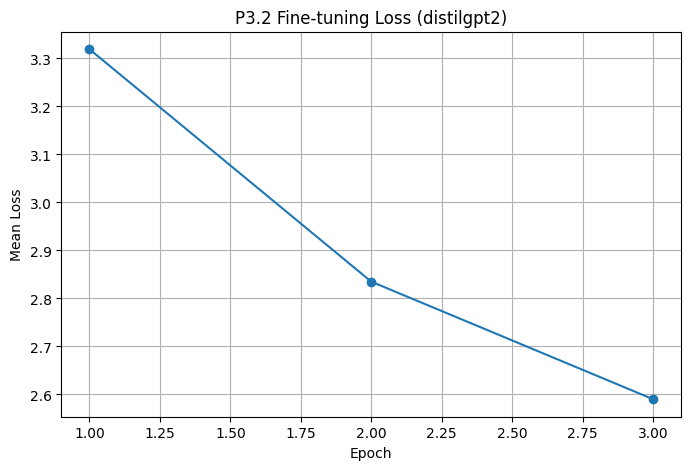


Generated text after fine-tuning:
Alice.”

“You’re just a simple
thing!” said the Pigeon.

“What did you say?” said Alice, who had been listening to the conversation, in an



In [85]:
# Fine-tune model
epochs_gpt2 = 3
optimizer_gpt2 = AdamW(gpt2_model.parameters(), lr=5e-5)

gpt2_losses = []

gpt2_model.train()
for epoch in range(epochs_gpt2):
    epoch_loss = 0
    num_batches = 0

    for batch in dataloader:
        batch_input_ids = batch[0].to(device)
        batch_attention_mask = batch[1].to(device)
        batch_labels = batch[2].to(device)

        optimizer_gpt2.zero_grad()
        outputs = gpt2_model(
            input_ids=batch_input_ids,
            attention_mask=batch_attention_mask,
            labels=batch_labels
        )
        loss = outputs.loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(gpt2_model.parameters(), 1.0)
        optimizer_gpt2.step()

        epoch_loss += loss.item()
        num_batches += 1

    mean_loss = epoch_loss / num_batches
    gpt2_losses.append(mean_loss)
    print(f"Epoch {epoch+1}/{epochs_gpt2}: Loss = {mean_loss:.4f}, "
          f"Perplexity = {np.exp(mean_loss):.4f}")


# Plot fine-tuning loss
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs_gpt2 + 1), gpt2_losses, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Mean Loss")
plt.title("P3.2 Fine-tuning Loss (distilgpt2)")
plt.grid(True)
plt.show()

# Generate text after fine-tuning
generated_after_ft = generate_gpt2_text(
    gpt2_model, gpt2_tokenizer, start_text="Alice", num_tokens=50
)
print("\nGenerated text after fine-tuning:")
print(generated_after_ft)


In [88]:
# Compare before and after fine-tuning
print("\n=== Before vs After Fine-tuning ===\n")
print("Before:")
print(generated_before_ft)
print("\nAfter:")
print(generated_after_ft)

# Compare with previous models
print("\n=== Comparison with other word-level models ===\n")

print("P2.1 Word-level GRU:")
print(generate_word_text(word_model, start_word="alice", num_tokens=50))

print("\nP2.2 GloVe GRU:")
print(generate_word_text(pretrained_model, start_word="alice", num_tokens=50))

print("\nP3.1 Decoder-only Transformer:")
print(generate_text_transformer(transformer_model, start_word="alice", num_tokens=50))

print("\nP3.2 Fine-tuned distilgpt2:")
print(generated_after_ft)

# Compare final perplexity
print("\n=== Perplexity comparison (final epoch) ===")
print(f"P2.1 Word-level GRU:             {np.exp(history.history['loss'][-1]):.4f}")
print(f"P2.2 GloVe GRU:                  {np.exp(history_pretrained.history['loss'][-1]):.4f}")
print(f"P3.1 Decoder-only Transformer:   {np.exp(transformer_losses[-1]):.4f}")
print(f"P3.2 Fine-tuned distilgpt2:      {np.exp(gpt2_losses[-1]):.4f}")


=== Before vs After Fine-tuning ===

Before:
Alice to Alice, and she went on: “_I shall
tell you the little thing that’s the most interesting thing
in history: _I_ like to
tell you the little thing that’s the most interesting thing

After:
Alice.”

“You’re just a simple
thing!” said the Pigeon.

“What did you say?” said Alice, who had been listening to the conversation, in an


=== Comparison with other word-level models ===

P2.1 Word-level GRU:
Alice got in the schoolroom and though this was by it and found a little hand in a very difficult question however she stretched her arms and the gryphon and the gryphon answered in the house if he in a tone of great other intellectual property infringement a defective or

P2.2 GloVe GRU:
Alice come here directly all the dormouse say and some of this they all not remember ever was not going out one of course house and after a doze but they very anxiously into its face was not a very small one of the next thing it was not be

P3.1 Decoder-only

FFrom the loss curve, the training loss decreases steadily during fine-tuning, which shows that the model is adapting to the new corpus. Even with only a few epochs, the improvement is already quite clear.

Comparing the generated text before and after fine-tuning, the difference is quite obvious. Before fine-tuning, the output is fluent but quite repetitive and generic, and does not really reflect the style of the book. After just 3 epochs of fine-tuning on the Alice corpus, the model starts to produce text that is much closer to the original style. For example, it generates dialogue patterns like “said the Pigeon” and includes character names such as “Alice” and “the Pigeon”, which are specific to the book. This suggests that fine-tuning on a small, domain-specific dataset can still be effective even with very limited training.

The perplexity of distilgpt2 after fine-tuning (13.33) is higher than the word-level GRU (1.85), GloVe GRU (3.24), and the decoder-only Transformer (1.53). However, this comparison is not entirely fair. distilgpt2 uses a BPE tokenizer with a much larger vocabulary (around 50,000 subword tokens), while the other models use a much smaller word-level vocabulary (3,533 words) built from this corpus. Because of this, the prediction task for distilgpt2 is inherently harder, which leads to higher perplexity values. Despite this, the generated text from distilgpt2 is clearly better in quality, with more natural sentences and more coherent dialogue that resembles the original book. This shows that perplexity is not always a reliable metric when comparing models with different tokenisation methods.